<a href="https://colab.research.google.com/github/DiabeticRetinopathy114/114_DR/blob/main/224x224%20Gaussian%20Filtered/Gaussian/test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

aptos2019_blindness_detection_path = kagglehub.competition_download('aptos2019-blindness-detection')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/aptos2019-blindness-detection/sample_submission.csv
/kaggle/input/aptos2019-blindness-detection/train.csv
/kaggle/input/aptos2019-blindness-detection/test.csv
/kaggle/input/aptos2019-blindness-detection/train_images/ef476be214d4.png
/kaggle/input/aptos2019-blindness-detection/train_images/6dcde47060f9.png
/kaggle/input/aptos2019-blindness-detection/train_images/ec363f48867b.png
/kaggle/input/aptos2019-blindness-detection/train_images/17f6c7072f61.png
/kaggle/input/aptos2019-blindness-detection/train_images/b49b2fac2514.png
/kaggle/input/aptos2019-blindness-detection/train_images/af6166d57f13.png
/kaggle/input/aptos2019-blindness-detection/train_images/8d13c46e7d75.png
/kaggle/input/aptos2019-blindness-detection/train_images/c3b15bf9b4bc.png
/kaggle/input/aptos2019-blindness-detection/train_images/be68322c7223.png
/kaggle/input/aptos2019-blindness-detection/train_images/88e4399d207c.png
/kaggle/input/aptos2019-blindness-detection/train_images/0243404e8a00.png
/kaggle/input

In [ ]:
import pandas as pd
import cv2
import os

from tqdm.notebook import tqdm

In [ ]:
file = pd.read_csv('/kaggle/input/aptos2019-blindness-detection/train.csv')

In [ ]:
file.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [ ]:
no_dr = 'No_DR/'
mild = 'Mild/'
moderate = 'Moderate/'
severe = 'Severe/'
proliferate_dr = 'Proliferate_DR/'

In [ ]:
train_y = file['diagnosis']
print(train_y.head())
# get the number of images per category
num_img_by_cat = (train_y.value_counts())
print(num_img_by_cat, type(num_img_by_cat))

0    2
1    4
2    1
3    0
4    0
Name: diagnosis, dtype: int64
diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64 <class 'pandas.core.series.Series'>


In [ ]:
sigmaX = 10

In [ ]:
for class_id in tqdm(sorted(train_y.unique())):
    if class_id == 0:
        for i, (idx, row) in tqdm(enumerate(file.loc[file['diagnosis'] == class_id].sample(num_img_by_cat[0],).iterrows())):
            read_path = '/kaggle/input/aptos2019-blindness-detection/train_images/' + row['id_code'] + '.png'
            write_path = '../input/gaussian_filtered_images/'+no_dr+row['id_code']+'.png'
            image = cv2.imread(read_path)
            gaussian = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0,0), sigmaX), -4, 128)
            gaussian = cv2.resize(gaussian, (224, 224))
            cv2.imwrite(write_path, gaussian)

    if class_id == 1:
        for i, (idx, row) in tqdm(enumerate(file.loc[file['diagnosis'] == class_id].sample(num_img_by_cat[1],).iterrows())):
            read_path = '/kaggle/input/aptos2019-blindness-detection/train_images/' + row['id_code'] + '.png'
            write_path = '../input/gaussian_filtered_images/'+mild+row['id_code']+'.png'
            image = cv2.imread(read_path)
            gaussian = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0,0), sigmaX), -4, 128)
            gaussian = cv2.resize(gaussian, (224, 224))
            cv2.imwrite(write_path, gaussian)

    if class_id == 2:
        for i, (idx, row) in tqdm(enumerate(file.loc[file['diagnosis'] == class_id].sample(num_img_by_cat[2],).iterrows())):
            read_path = '/kaggle/input/aptos2019-blindness-detection/train_images/' + row['id_code'] + '.png'
            write_path = '../input/gaussian_filtered_images/'+moderate+row['id_code']+'.png'
            image = cv2.imread(read_path)
            gaussian = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0,0), sigmaX), -4, 128)
            gaussian = cv2.resize(gaussian, (224, 224))
            cv2.imwrite(write_path, gaussian)

    if class_id == 3:
        for i, (idx, row) in tqdm(enumerate(file.loc[file['diagnosis'] == class_id].sample(num_img_by_cat[3],).iterrows())):
            read_path = '/kaggle/input/aptos2019-blindness-detection/train_images/' + row['id_code'] + '.png'
            write_path = '../input/gaussian_filtered_images/'+severe+row['id_code']+'.png'
            image = cv2.imread(read_path)
            gaussian = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0,0), sigmaX), -4, 128)
            gaussian = cv2.resize(gaussian, (224, 224))
            cv2.imwrite(write_path, gaussian)

    if class_id == 4:
        for i, (idx, row) in tqdm(enumerate(file.loc[file['diagnosis'] == class_id].sample(num_img_by_cat[4],).iterrows())):
            read_path = '/kaggle/input/aptos2019-blindness-detection/train_images/' + row['id_code'] + '.png'
            write_path = '../input/gaussian_filtered_images/'+proliferate_dr+row['id_code']+'.png'
            image = cv2.imread(read_path)
            gaussian = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0,0), sigmaX), -4, 128)
            gaussian = cv2.resize(gaussian, (224, 224))
            cv2.imwrite(write_path, gaussian)

  0%|          | 0/5 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

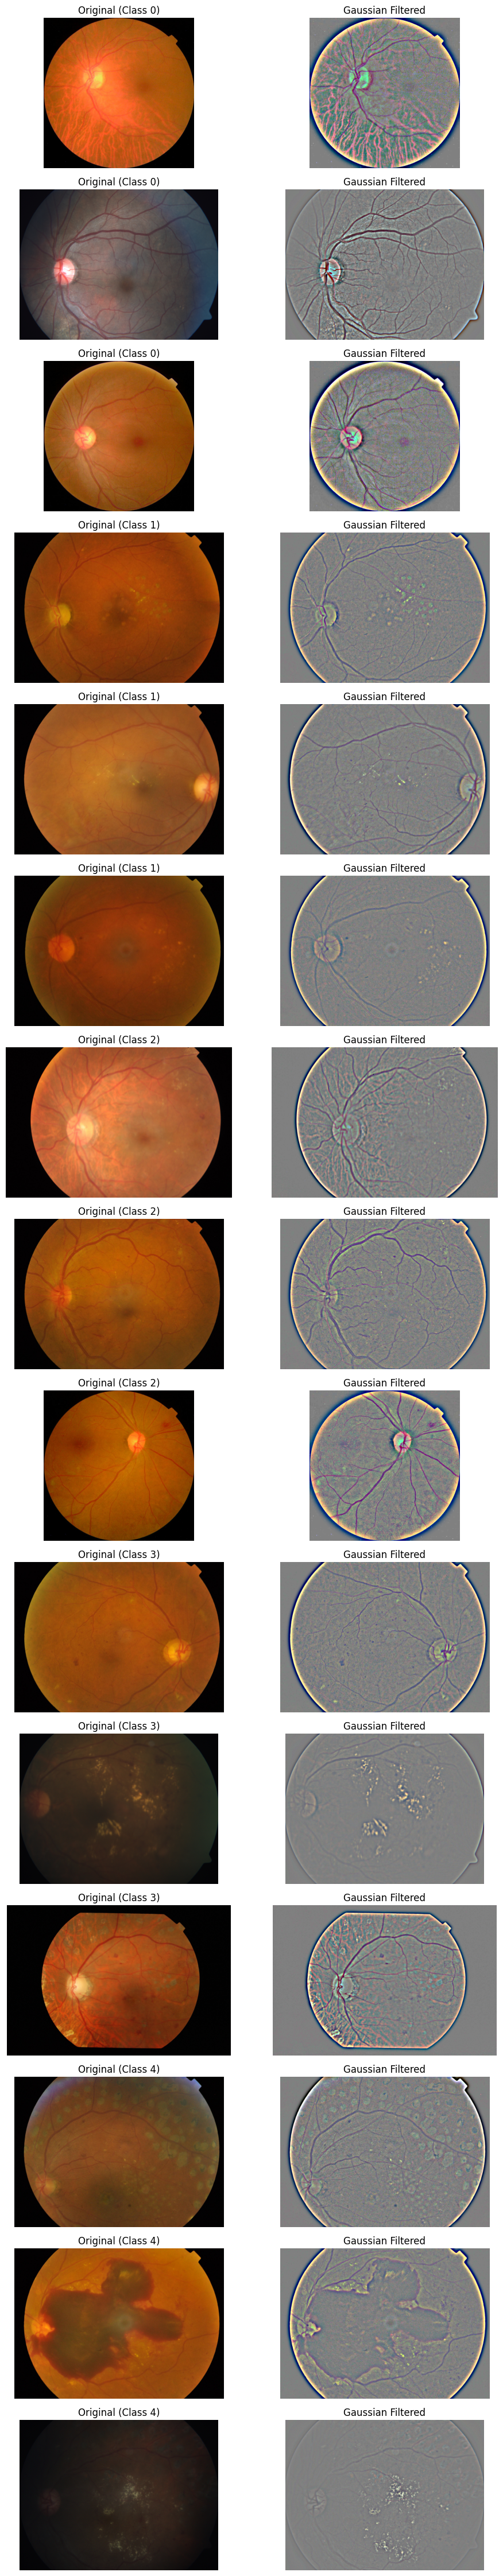

In [ ]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import random

sigmaX = 20

# 隨機從每個 diagnosis 類別選幾張圖片 (例如每類選3張)
num_samples_per_class = 3

# 設定圖檔路徑
image_dir = '/kaggle/input/aptos2019-blindness-detection/train_images/'

# 總資料表 (假設你已經有 file DataFrame)
# file = pd.read_csv('/kaggle/input/aptos2019-blindness-detection/train.csv')

def display_gaussian_samples(file, num_samples_per_class=3):
    selected_rows = []

    # 每個 diagnosis 類別隨機抽 num_samples_per_class 張
    for class_id in sorted(file['diagnosis'].unique()):
        samples = file[file['diagnosis'] == class_id].sample(num_samples_per_class, random_state=42)
        selected_rows.extend(samples.to_dict('records'))

    # 計算要畫的行數與欄數（每張圖顯示兩張圖：原圖+高斯）
    num_rows = len(selected_rows)
    plt.figure(figsize=(10, num_rows * 3))

    for idx, row in enumerate(selected_rows):
        id_code = row['id_code']
        read_path = image_dir + id_code + '.png'
        image = cv2.imread(read_path)

        if image is None:
            print(f"Failed to load image: {read_path}")
            continue

        # Resize 成 224x224
        image = cv2.resize(image, (224, 224))

        # 轉成 RGB 格式
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 套用高斯模糊與加權
        gaussian = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0,0), sigmaX), -4, 128)
        gaussian_rgb = cv2.cvtColor(gaussian, cv2.COLOR_BGR2RGB)

        # 畫原圖
        plt.subplot(num_rows, 2, idx*2 + 1)
        plt.imshow(image_rgb)
        plt.title(f'Original (Class {row["diagnosis"]})')
        plt.axis('off')

        # 畫高斯濾波圖
        plt.subplot(num_rows, 2, idx*2 + 2)
        plt.imshow(gaussian_rgb)
        plt.title('Gaussian Filtered')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# 呼叫函式
display_gaussian_samples(file, num_samples_per_class=3)
